In [1]:
from julia.api import Julia
from julia import Main

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

import scipy.special as sp
import os

import pathlib
from pathlib import Path
import json

#fitters

import pybobyqa
import time
import cma
import csv

Which Fit?

In [2]:
fit_name = "MAP-FD"

Read Files

In [3]:
Main.fit_name = str(fit_name)

TMD_fitting_root = "../"
def include(name):
    path = os.path.join(TMD_fitting_root, name)
    Main.eval(f'include(raw"{path}")')

include(f"Cards/{fit_name}.jl")
include("DY/DY_table_FD.jl")

# Data
data_name = Main.data_name
table_name = Main.table_name

file_root = f"../Data/{data_name}/Cutted/DY"
matrix_root = f"../Data/{data_name}/Covariance_Matrices/DY"
table_root = f"../Tables_JLD2/{table_name}/DY"

initial_params = Main.initial_params

In [4]:
def to_float64(df):
    num_cols = df.select_dtypes(include=["number"]).columns
    df[num_cols] = df[num_cols].astype("float64")
    return df

df_predictions = dict([])

By file or by experiment?

In [5]:
data_selections = "by_experiment"  # "by_file" or "by_experiment"

In [6]:
experiments =[
    'ATLAS_7',
    'ATLAS_8', 
    'ATLAS_13', 
    'CDF_I',
    'CDF_II',
    'CMS_7',
    'CMS_8',
    'CMS_13',    
    'D0_I',
    'D0_II',
    'D0_II_mu',
    'E288',
    'E605',
    'E772',
    'LHCb_7',
    'LHCb_8',
    'LHCb_13',    
    #'PHENIX',
    'STAR'
]

#["E288","E605","E772","ATLAS", "CMS", "D0", "CDF", "LHCb", "PHENIX", "STAR"]

if data_selections == "by_file":
    file_names = [

    #----------------------------------------------------------------------------
    # ATLAS
    #----------------------------------------------------------------------------

    #"ATLAS/ATLAS_7TeV_y_0_1.csv",
    #"ATLAS/ATLAS_7TeV_y_1_2.csv",
    #"ATLAS/ATLAS_7TeV_y_2_2.4.csv",

    #"ATLAS/ATLAS_8TeV_Q_44_66.csv",
    #"ATLAS/ATLAS_8TeV_Q_116_150.csv",

    #"ATLAS/ATLAS_8TeV_y_0_0.4.csv"
    #"ATLAS/ATLAS_8TeV_y_0.4_0.8.csv"
    #"ATLAS/ATLAS_8TeV_y_0.8_1.2.csv"
    #"ATLAS/ATLAS_8TeV_y_1.2_1.6.csv",
    #"ATLAS/ATLAS_8TeV_y_1.6_2.csv",
    #"ATLAS/ATLAS_8TeV_y_2_2.4.csv",

    #----------------------------------------------------------------------------
    # CDF
    #----------------------------------------------------------------------------

    #"CDF/CDF_RunI.csv",
    #"CDF/CDF_RunII.csv",

    #----------------------------------------------------------------------------
    # CMS
    #----------------------------------------------------------------------------

    #"CMS/CMS_7TeV.csv",
    #"CMS/CMS_8TeV.csv",
    
    #"CMS/CMS_13TeV_y_0_0.4.csv",
    #"CMS/CMS_13TeV_y_0.4_0.8.csv",
    #"CMS/CMS_13TeV_y_0.8_1.2.csv",
    #"CMS/CMS_13TeV_y_1.2_1.6.csv",
    #"CMS/CMS_13TeV_y_1.6_2.4.csv",

    #----------------------------------------------------------------------------
    # D0
    #----------------------------------------------------------------------------

    #"D0/D0_RunI.csv",
    #"D0/D0_RunII.csv",
    #"D0/D0_RunIImu.csv",

    #----------------------------------------------------------------------------
    # LHCb
    #----------------------------------------------------------------------------

    #"LHCb/LHCb_7TeV.csv",
    #"LHCb/LHCb_8TeV.csv",
    #"LHCb/LHCb_13TeV.csv",

    #----------------------------------------------------------------------------
    # Phenix
    #----------------------------------------------------------------------------

    #"PHENIX/PHENIX_200.csv",

    #----------------------------------------------------------------------------
    # STAR
    #----------------------------------------------------------------------------

    #"STAR/STAR_510.csv",

    #----------------------------------------------------------------------------
    # E288
    #----------------------------------------------------------------------------

    #"E288/E288_200_Q_4_5.csv",
    #"E288/E288_200_Q_5_6.csv",
    #"E288/E288_200_Q_6_7.csv",
    #"E288/E288_200_Q_7_8.csv",
    #"E288/E288_200_Q_8_9.csv",
    #"E288/E288_200_Q_10_11.csv",

    #"E288/E288_300_Q_4_5.csv",
    #"E288/E288_300_Q_5_6.csv",
    #"E288/E288_300_Q_6_7.csv",
    #"E288/E288_300_Q_7_8.csv",
    #"E288/E288_300_Q_8_9.csv",
    #"E288/E288_300_Q_10_11.csv",
    #"E288/E288_300_Q_11_12.csv",

    #"E288/E288_400_Q_5_6.csv",
    #"E288/E288_400_Q_6_7.csv",
    #"E288/E288_400_Q_7_8.csv",
    #"E288/E288_400_Q_8_9.csv",
    #"E288/E288_400_Q_10_11.csv",
    #"E288/E288_400_Q_11_12.csv",
    #"E288/E288_400_Q_12_13.csv",
    #"E288/E288_400_Q_13_14.csv",

    #----------------------------------------------------------------------------
    # E605
    #----------------------------------------------------------------------------

    #"E605/E605_Q_7_8.csv",
    #"E605/E605_Q_8_9.csv",
    #"E605/E605_Q_10.5_11.5.csv",
    #"E605/E605_Q_11.5_13.5.csv",
    #"E605/E605_Q_13.5_18.csv",

    #----------------------------------------------------------------------------
    # E772
    #----------------------------------------------------------------------------

    #"E772/E772_Q_5_6.csv",
    #"E772/E772_Q_6_7.csv",
    #"E772/E772_Q_7_8.csv",
    #"E772/E772_Q_8_9.csv",
    #"E772/E772_Q_11_12.csv",
    #"E772/E772_Q_12_13.csv",
    #"E772/E772_Q_13_14.csv",
    #"E772/E772_Q_14_15.csv",
    ]

In [7]:
from pathlib import Path

if data_selections == "by_experiment":
    file_names = []
    for experiment in experiments:
        exp_dir = Path(file_root) / experiment
        for p in sorted(exp_dir.glob("*.csv")):
            file_names.append(str(Path(experiment) / p.name)) 

display(file_names)

['ATLAS_7\\ATLAS7-00y10.csv',
 'ATLAS_7\\ATLAS7-10y20.csv',
 'ATLAS_7\\ATLAS7-20y24.csv',
 'ATLAS_8\\ATLAS8-00y04.csv',
 'ATLAS_8\\ATLAS8-04y08.csv',
 'ATLAS_8\\ATLAS8-08y12.csv',
 'ATLAS_8\\ATLAS8-116Q150.csv',
 'ATLAS_8\\ATLAS8-12y16.csv',
 'ATLAS_8\\ATLAS8-16y20.csv',
 'ATLAS_8\\ATLAS8-20y24.csv',
 'ATLAS_8\\ATLAS8-46Q66.csv',
 'ATLAS_13\\ATLAS13.csv',
 'CDF_I\\CDF1.csv',
 'CDF_II\\CDF2.csv',
 'CMS_7\\CMS7.csv',
 'CMS_8\\CMS8.csv',
 'CMS_13\\CMS13-00y04.csv',
 'CMS_13\\CMS13-04y08.csv',
 'CMS_13\\CMS13-08y12.csv',
 'CMS_13\\CMS13-12y16.csv',
 'CMS_13\\CMS13-16y24.csv',
 'D0_I\\D01.csv',
 'D0_II\\D02.csv',
 'D0_II_mu\\D02mu.csv',
 'E288\\E228-200-4Q5.csv',
 'E288\\E228-200-5Q6.csv',
 'E288\\E228-200-6Q7.csv',
 'E288\\E228-200-7Q8.csv',
 'E288\\E228-200-8Q9.csv',
 'E288\\E228-300-11Q12.csv',
 'E288\\E228-300-4Q5.csv',
 'E288\\E228-300-5Q6.csv',
 'E288\\E228-300-6Q7.csv',
 'E288\\E228-300-7Q8.csv',
 'E288\\E228-300-8Q9.csv',
 'E288\\E228-400-11Q12.csv',
 'E288\\E228-400-12Q13.csv',
 'E

Read Data

In [8]:
data_list = dict()
matrix_list = dict()

for file in tqdm(file_names):

    df_data = to_float64(pd.read_csv(f"{file_root}/{file}"))
    data_list[file] = df_data
    
    matrix = to_float64(pd.read_csv(f"{matrix_root}/{file}"))
    matrix_list[file] = matrix

100%|██████████| 59/59 [00:00<00:00, 323.06it/s]


Prediction

In [9]:
Params = Main.Params_Struct(*[np.float32(x) for x in initial_params]) 
#Main.set_params(Main.VRAM, Params) 

for i in range(10):
    Params = Main.Params_Struct(*[np.float32(x) for x in initial_params])                  
    predictions,t = Main.xsec_dict(Main.rel_paths, Main.VRAM)
    print(round(t*1000,2), "ms")

390.58 ms
73.25 ms
72.67 ms
75.26 ms
73.69 ms
72.91 ms
72.71 ms
72.67 ms
73.67 ms
72.71 ms


In [10]:
def get_file_length():

    file_lengths = dict()

    for file in file_names:

        df = to_float64(pd.read_csv(f"{file_root}/{file}"))

        file_lengths[file] = len(df)

    return file_lengths

file_lengths = get_file_length()

In [11]:
def _norm(p: str) -> str:
    return os.path.normpath(p).replace('\\', '/')

def prediction_reformat(predictions):
    preds = {_norm(k): v for k, v in predictions.items()}  # normalize keys once
    df_predictions = {}

    for file in file_names:
        n = file_lengths[file]
        base = os.path.splitext(file)[0]
        xs = []
        for i in range(n):
            table_path = _norm(os.path.join(table_root, f"{base}/{i}.jld2"))
            xs.append(preds[table_path])
        df_predictions[file] = np.array(xs)

    return df_predictions

df_predictions = prediction_reformat(predictions)


Chi2

In [12]:
ASWZ_b_array = np.linspace(0.12,0.78,12)*5.067731
ASWZ_prediction = np.array([
    -0.08158508158508182,
    -0.1701631701631705,
    -0.2400932400932403,
    -0.34265734265734293,
    -0.37062937062937085,
    -0.4265734265734267,
    -0.4498834498834501,
    -0.44522144522144536,
    -0.4965034965034967,
    -0.5710955710955714,
    -0.6363636363636365,
    -0.7016317016317017
    ])
ASWZ_upper = np.array([
    0.18414918414918402,
    0.11421911421911402,
    0.09557109557109533,
    0.002331002331002141,
    0.016317016317016098,
    -0.034965034965035224,
    -0.034965034965035224,
    -0.011655011655011815,
    -0.034965034965035224,
    -0.05361305361305391,
    -0.05827505827505863,
    -0.04895104895104918
    ])
ASWZ_error = np.array(ASWZ_upper) - np.array(ASWZ_prediction)

def chi2_lattice(): 
    CS_list = []
    for b in ASWZ_b_array :
        Q = 2.0
        CS = Main.CS_total_func(b, Q)
        CS_list.append(CS)
    chi2dN = np.sum( (CS_list - ASWZ_prediction)**2 / ASWZ_error**2 ) / len(ASWZ_b_array)
    return chi2dN

def timed(func):
    t0 = time.perf_counter()
    out = func()
    return out, time.perf_counter() - t0

#chi2dN, t = timed(chi2_lattice)
#print("χ^2/N from LATTICE =", chi2dN, ", took", round(t, 4), "seconds")

In [13]:
def get_chi2dN(df_predictions):

    N_list = dict()
    chi2dN_list = dict()
    chi2_total = 0.0
    N_total = 0

    for file in file_names:

        data_xsec = data_list[file]["xsec"].to_numpy()
        pred_xsec = df_predictions[file]
        diff_xsec = data_xsec - pred_xsec

        covariance_matrix_inv = matrix_list[file].to_numpy()

        N = len(data_xsec)

        chi2 = diff_xsec @ covariance_matrix_inv @ diff_xsec

        chi2_total += chi2
        N_total += N
        chi2dN_list[file] = float(round(chi2/N, 2))
        N_list[file] = N

    chi2dN = chi2_total / N_total
    return chi2dN, chi2dN_list, N_list

chi2dN, chi2dN_list, N_list = get_chi2dN(df_predictions)

print(f"Total χ^2/N = {chi2dN:.2f}")
display(chi2dN_list)

Total χ^2/N = 1.25


{'ATLAS_7\\ATLAS7-00y10.csv': 9.85,
 'ATLAS_7\\ATLAS7-10y20.csv': 5.66,
 'ATLAS_7\\ATLAS7-20y24.csv': 3.29,
 'ATLAS_8\\ATLAS8-00y04.csv': 0.26,
 'ATLAS_8\\ATLAS8-04y08.csv': 0.16,
 'ATLAS_8\\ATLAS8-08y12.csv': 0.05,
 'ATLAS_8\\ATLAS8-116Q150.csv': 0.51,
 'ATLAS_8\\ATLAS8-12y16.csv': 0.17,
 'ATLAS_8\\ATLAS8-16y20.csv': 0.16,
 'ATLAS_8\\ATLAS8-20y24.csv': 0.22,
 'ATLAS_8\\ATLAS8-46Q66.csv': 6.05,
 'ATLAS_13\\ATLAS13.csv': 15.33,
 'CDF_I\\CDF1.csv': 0.71,
 'CDF_II\\CDF2.csv': 0.37,
 'CMS_7\\CMS7.csv': 1.26,
 'CMS_8\\CMS8.csv': 1.72,
 'CMS_13\\CMS13-00y04.csv': 0.74,
 'CMS_13\\CMS13-04y08.csv': 0.55,
 'CMS_13\\CMS13-08y12.csv': 0.14,
 'CMS_13\\CMS13-12y16.csv': 0.14,
 'CMS_13\\CMS13-16y24.csv': 0.17,
 'D0_I\\D01.csv': 0.98,
 'D0_II\\D02.csv': 1.35,
 'D0_II_mu\\D02mu.csv': 0.55,
 'E288\\E228-200-4Q5.csv': 1.3,
 'E288\\E228-200-5Q6.csv': 0.07,
 'E288\\E228-200-6Q7.csv': 0.52,
 'E288\\E228-200-7Q8.csv': 0.42,
 'E288\\E228-200-8Q9.csv': 0.37,
 'E288\\E228-300-11Q12.csv': 0.99,
 'E288\\E228-300

Objective

In [14]:
def objective(params):
    try:
        params_cl = Main.Params_Struct(*[np.float32(x) for x in params])
        Main.set_params(Main.VRAM, params_cl)

        predictions, t = Main.xsec_dict(Main.rel_paths, Main.VRAM)

        df_predictions = prediction_reformat(predictions)
        chi2dN, _, _ = get_chi2dN(df_predictions)

        if not np.isfinite(chi2dN): 
            return 1e5
        return chi2dN

    except Exception as e:
        return 1e5

objective(initial_params)

np.float64(1.2506255682090441)

Bounds

In [15]:
bounds_raw = [
    (0.2, 1.0),   

    (-20.0, 20.0),   
    (-30.0, 30.0),

    (-20.0, 20.0),   
    (-20.0, 20.0),    
    (-20.0, 20.0),  

    (-20.0, 20.0),   
    (-20.0, 20.0),  
    (-20.0, 20.0),   
    (-20.0, 20.0),    
    (-20.0, 20.0),  
    (-20.0, 20.0),    
]

lower_bounds, upper_bounds = np.array(list(zip(*bounds_raw)))

def objective_normalized(params):

    normalized_params = lower_bounds + params * (upper_bounds - lower_bounds)

    return objective(normalized_params)

def objective_log(params):
    return np.log10(objective_normalized(params))

def normalize_params(params):
    return (params - lower_bounds) / (upper_bounds - lower_bounds)

def denormalize_params(params):
    return lower_bounds + params * (upper_bounds - lower_bounds)


theta0 = normalize_params(np.array(initial_params))
dim = len(bounds_raw)

Setting 1 (1.501)

In [16]:
import numpy as np
import time
import cma

def make_progress_objective(f, delta=1e-3):
    state = {
        "best": np.inf,   # best log10(chi2)
        "xbest": None,    # best params
        "nevals": 0,
        "t0": time.time(),
    }

    def wrapped(x):
        val = f(x)
        state["nevals"] += 1

        # print only when improved by at least delta in log-space
        if state["best"] - val >= delta:
            state["best"] = val
            state["xbest"] = np.array(x, copy=True)
            minutes = (time.time() - state["t0"]) / 60.0

            # short, readable param print; adjust precision if you like
            x_str = np.array2string(state["xbest"], precision=7, separator=", ")

            print(
                f"[CMA-ES] eval {state['nevals']}: "
                f"new best χ² = {10**val:.3f}, "
                f"params = {x_str}, "
                f"t = {minutes:.0f} min"
            )

        return val

    # expose state so you can inspect after optimization
    wrapped.state = state
    return wrapped

# Wrap your log-chi2 objective
objective_with_progress = make_progress_objective(objective_log, delta=1e-3)

dim = len(theta0)

res = cma.fmin(
    objective_with_progress,
    theta0,          # assumed scaled to [0,1]^dim
    0.3,             # wider start to help global search
    {
        "bounds": [0.0, 1.0],
        "maxfevals": 500_000,
        "popsize": 8 + int(4 * np.log(dim)),  # larger than default for more exploration
        "CMA_active": True,
        "CMA_elitist": True,
        "CMA_diagonal": 50,   # first 50 iters diagonal-only for robust global-ish search
        "verb_disp": 0,       # silence built-in logs; we use our own
    },
    restarts=8,
    incpopsize=2,
)

# After this, compare against your known best:
# f_start = objective_log(theta0)
# if f_start < res[1]: use theta0 instead.


[CMA-ES] eval 1: new best χ² = 100000.000, params = [0.1724023, 0.6760454, 0.4364881, 0.980764 , 0.6500745, 0.4616416,
 0.8240127, 0.0515339, 0.9289409, 0.5038882, 0.8982385, 0.8825915], t = 0 min
[CMA-ES] eval 18: new best χ² = 25.384, params = [0.3925203, 0.9333076, 0.0776323, 0.6883562, 0.5317822, 0.5636618,
 0.7775328, 0.0961239, 0.5609772, 0.6433993, 0.9537929, 0.5486901], t = 0 min


KeyboardInterrupt: 

In [ ]:
raw_params = np.array([3.3679703e-01, 6.3636514e-01, 2.2955760e-05, 5.0015011e-01, 5.1872859e-01,
 4.9114794e-01, 7.5560013e-01, 2.1501996e-01, 5.0017348e-01, 5.1459477e-01,
 9.9958292e-01, 4.9506670e-01])

optimal_params = denormalize_params(raw_params)
rounded = [float(f"{x:.{3}g}") for x in optimal_params]
print(rounded)

[0.469, 5.45, -30.0, 0.006, 0.749, -0.354, 10.2, -11.4, 0.00694, 0.584, 20.0, -0.197]


Setting 2

In [ ]:
import numpy as np
import time
import cma

def make_progress_objective(f, delta=1e-3):
    state = {
        "best": np.inf,   # best log10(chi2)
        "xbest": None,    # best params
        "nevals": 0,
        "t0": time.time(),
    }

    def wrapped(x):
        val = f(x)
        state["nevals"] += 1

        # print only when improved by at least delta in log-space
        if state["best"] - val >= delta:
            state["best"] = val
            state["xbest"] = np.array(x, copy=True)
            minutes = (time.time() - state["t0"]) / 60.0

            # short, readable param print; adjust precision if you like
            x_str = np.array2string(state["xbest"], precision=4, separator=", ")

            print(
                f"[CMA-ES] eval {state['nevals']}: "
                f"new best χ² = {10**val:.3f}, "
                f"params = {x_str}, "
                f"t = {minutes:.0f} min"
            )

        return val

    # expose state so you can inspect after optimization
    wrapped.state = state
    return wrapped

# Wrap your log-chi2 objective
objective_with_progress = make_progress_objective(objective_log, delta=1e-3)

dim = len(theta0)

res = cma.fmin(
    objective_with_progress,
    theta0,
    0.25,
    {
        "bounds": [0.0, 1.0],
        "maxfevals": 500_000,
        "popsize": 4 + int(3 * np.log(dim)),
        "CMA_active": True,
        "CMA_elitist": True,
        "CMA_diagonal": 100,
        "verb_disp": 0,
    },
    restarts=6,
    incpopsize=2,
)

# After the run, best from wrapper:
best_logchi2 = objective_with_progress.state["best"]
best_params = objective_with_progress.state["xbest"]
best_chi2 = 10**best_logchi2

print("Final best χ²:", best_chi2)
print("Final best params:", best_params)


[CMA-ES] eval 1: new best χ² = 100000.000, params = [0.4718, 0.5396, 0.6215, 0.0075, 0.7097, 0.2386, 0.367 , 0.6156, 0.5388,
 0.3023, 0.9211, 0.9055], t = 0 min
[CMA-ES] eval 18: new best χ² = 81.260, params = [0.7934, 0.5126, 0.2819, 0.6464, 0.6677, 0.8168, 0.5751, 0.4237, 0.6551,
 0.5984, 0.8564, 0.556 ], t = 0 min
[CMA-ES] eval 98: new best χ² = 58.740, params = [0.517 , 0.4321, 0.4234, 0.5827, 0.9192, 0.8831, 0.4687, 0.1928, 0.5905,
 0.6249, 0.9187, 0.8543], t = 0 min
[CMA-ES] eval 122: new best χ² = 42.844, params = [0.8936, 0.8013, 0.7667, 0.9745, 0.7348, 0.8255, 0.2795, 0.4835, 0.337 ,
 0.6655, 0.5841, 0.5855], t = 0 min
[CMA-ES] eval 150: new best χ² = 40.374, params = [1.    , 0.7641, 0.513 , 0.6235, 0.5716, 0.9324, 0.3367, 0.6541, 0.435 ,
 0.9511, 0.6872, 0.7548], t = 0 min
[CMA-ES] eval 190: new best χ² = 36.246, params = [0.965 , 0.439 , 0.4121, 0.7455, 0.7872, 0.5791, 0.5726, 0.6423, 0.8197,
 0.7053, 0.6981, 0.8368], t = 0 min
[CMA-ES] eval 217: new best χ² = 30.108, param

KeyboardInterrupt: 

In [ ]:
import numpy as np
import time
import cma

# Progress wrapper (unchanged except adding minutes + starting best)
def make_progress_objective(f, delta=1e-3):
    state = {
        "best": np.inf,
        "nevals": 0,
        "t0": time.time(),
    }

    def wrapped(x):
        val = f(x)
        state["nevals"] += 1

        # print only when improved by at least delta in log-space
        if state["best"] - val >= delta:
            state["best"] = val
            minutes = (time.time() - state["t0"]) / 60.0
            print(
                f"[CMA-ES] eval {state['nevals']}: "
                f"new best χ² = {10**val:.6f}, "
                f"t = {minutes:.2f} min"
            )

        return val

    return wrapped

objective_with_progress = make_progress_objective(objective_log, delta=1e-3)

dim = len(theta0)

# Slightly larger popsize than default for more global power
popsize = 4 + int(6 * np.log(dim))   # ~20 for dim ~12
sigma0 = 0.35                        # 25% of box: broad but not insane

res = cma.fmin(
    objective_with_progress,
    theta0,          # assumed scaled to [0,1]^dim
    sigma0,
    {
        "bounds": [0.0, 1.0],
        "maxfevals": 500_000,
        "popsize": popsize,
        "CMA_active": True,
        "CMA_elitist": True,
        # Diagonal for first 100 generations of EACH restart:
        # good global-ish warmup, then switch to full C for curvature.
        "CMA_diagonal": 100,
        "verb_disp": 0,
    },
    restarts=6,      # IPOP restarts
    incpopsize=2,    # double popsize each restart
)


c:\Users\congyue zhang\AppData\Local\Programs\Python\Python311\Lib\site-packages\cma\evolution_strategy.py:1312: UserWarning: Sampling standard deviation i=0 (and 11 others) at iteration 0 multiplied by 0.9523809523809524 to stds[0]=0.3333333333333333
  warnings.warn("Sampling standard deviation i={0}{4} at iteration {1}"


[CMA-ES] eval 1: new best χ² = 100000.000000, t = 0.00 min


KeyboardInterrupt: 

In [ ]:
res

(array([0.5429518 , 0.04418192, 0.50090256, 0.49866799, 0.5004088 ,
        0.62799351, 0.08322038, 0.48429683, 0.79174384, 0.92569171,
        0.5534801 , 0.81685187]),
 0.21596858112584524,
 8749,
 10073,
 1,
 array([0.7059111 , 0.54219636, 0.53626915, 0.54960902, 0.57836315,
        0.54670349, 0.44546985, 0.64143283, 0.86508919, 0.60418451,
        0.55282239, 0.79295934]),
 array([0.21145736, 0.20581472, 0.1928199 , 0.20397958, 0.21229926,
        0.20121308, 0.20992455, 0.19864116, 0.21161644, 0.2019715 ,
        0.19422429, 0.20526242]),
 {'maxfevals': 10000},
 {'maxfevals': 10000},
 <cma.logger.CMADataLogger at 0x27181075710>)

Global Minimize

Py-Bobyqa Fit

In [ ]:
random_flag = False
N_trials = 1
alpha = 9.0

for i in tqdm(range(N_trials)):
    if random_flag:
        rng = np.random.default_rng()      
        theta0 = None
        while True:
            cand = rng.beta(alpha, alpha, size=dim)   
            val  = float(objective_log(cand))
            if val < 1.0:
                theta0 = cand
                break
        print(f"initial params generated: {round(val,2)}")

    res = pybobyqa.solve(
            objective_log, theta0,
            bounds=(np.zeros(dim), np.ones(dim)),
            maxfun=30000,
            rhobeg=0.15,
            rhoend=1e-5,
            scaling_within_bounds=True,
            seek_global_minimum=True, 
        )
    
    best_chi2dN = 10**(res.f)
    optimal_params_normalized = res.x
    optimal_params = denormalize_params(optimal_params_normalized)

    fmt = lambda x: f"{x:.3g}"     
    with open("results.csv", "a", newline="") as f:
        csv.writer(f).writerow([i, fmt(best_chi2dN), *map(fmt, np.asarray(optimal_params))])

100%|██████████| 1/1 [01:51<00:00, 111.06s/it]


Fit Results

In [ ]:
optimal_params_normalized = res.x
optimal_params = denormalize_params(optimal_params_normalized)
best_chi2dN = 10**(res.f)
N_evals = res.nf

if res.flag == 0:
    print("Optimization successful.")
else:
    print("Optimization failed.")

print()
print("# of Evals =", N_evals)
print()
print("Best χ^2/N =", round(best_chi2dN, 2))
print()
print("Best parameters (normalized):")
print(", ".join(f"{x:.3g}" for x in optimal_params_normalized))
print()
print("Best parameters (unnormalized):")
print(", ".join(f"{x:.3g}" for x in optimal_params))

Optimization successful.

# of Evals = 1016

Best χ^2/N = 1.82

Best parameters (normalized):
0.375, 0.551, 0.433, 0.494, 0.495, 0.5, 0.46, 0.575, 0.364, 0.52, 0.5, 0.554

Best parameters (unnormalized):
0.5, 2.02, -4.04, -0.222, -0.197, 0.00404, -1.59, 3, -5.44, 0.817, -0.00398, 2.17


In [ ]:
res.flag

0

In [17]:
display(initial_params)

array([ 4.69e-01,  5.45e+00, -3.00e+01,  6.00e-03,  7.49e-01, -3.54e-01,
        1.02e+01, -1.14e+01,  6.94e-03,  5.84e-01,  2.00e+01, -1.97e-01])

In [19]:
params_cl = Main.Params_Struct(*[np.float32(x) for x in initial_params])
Main.set_params(Main.VRAM, params_cl)
predictions,t = Main.xsec_dict(Main.rel_paths, Main.VRAM)

df_predictions = prediction_reformat(predictions)
chi2dN, chi2dN_list, N_list = get_chi2dN(df_predictions)

df = pd.DataFrame.from_dict(chi2dN_list, orient="index", columns=["χ^2/N"])
df["N"] = pd.Series(N_list)
df = df.reset_index().rename(columns={"index":"experiment"})
df["experiment"] = df["experiment"].apply(lambda s: Path(s).stem)
df = df[["experiment", "N", "χ^2/N"]]

styled = (
    df.style
      .set_properties(**{"text-align": "center"})           
      .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])  
)
fmt = {col: "{:.2f}" for col in df.select_dtypes(include="float").columns}
display(styled.format(fmt))

total_N = int(df["N"].sum())
print("Total N:", total_N)

,experiment,N,χ^2/N
0,ATLAS7-00y10,6,9.85
1,ATLAS7-10y20,6,5.66
2,ATLAS7-20y24,6,3.29
3,ATLAS8-00y04,6,0.26
4,ATLAS8-04y08,6,0.16
5,ATLAS8-08y12,6,0.05
6,ATLAS8-116Q150,8,0.51
7,ATLAS8-12y16,6,0.17
8,ATLAS8-16y20,6,0.16
9,ATLAS8-20y24,6,0.22


Total N: 460


Plots

In [20]:
plots_list = dict([])

for file in file_names:

    df = pd.read_csv(f"{file_root}/{file}")

    qT_array = df["qT_mean"]
    data_array = df["xsec"]
    prediction_array = df_predictions[file]
    
    ratio_array = np.array(prediction_array)/df["xsec"]
    matrix = np.linalg.inv(matrix_list[file].to_numpy())
    error_uncor_array = np.sqrt(np.diag(matrix))
    error_uncor_ratio_array = error_uncor_array/data_array

    df_plot = pd.DataFrame([])

    df_plot["qT_array"] = qT_array
    df_plot["data_array"] = data_array
    df_plot["prediction_array"] = prediction_array
    df_plot["ratio_array"] = ratio_array
    df_plot["error_uncor_array"] = error_uncor_array
    df_plot["error_uncor_ratio_array"] = error_uncor_ratio_array

    plots_list[file] = df_plot

def fmt(x):  
    return f"{float(x):g}"

#for file in list(plots_list.keys()):
#    source_df = pd.read_csv(f"{file_root}/{file}")
#
#    q_bucket = source_df["Q_mean"].round(6)
#    if q_bucket.nunique() == 1:
#        continue
#
#    plot_df = plots_list[file]
#    base_name = Path(file).stem
#
#    for _, row_index in source_df.groupby(q_bucket, sort=False).groups.items():
#        plot_df_split = plot_df.iloc[row_index].reset_index(drop=True)
#
#        qmin_vals = source_df.loc[row_index, "Q_min"].unique()
#        qmax_vals = source_df.loc[row_index, "Q_max"].unique()
#
#        if len(qmin_vals) == 1 and len(qmax_vals) == 1:
#            qmin, qmax = qmin_vals[0], qmax_vals[0]
#        else:
#
#            qmin = source_df.loc[row_index, "Q_min"].min()
#            qmax = source_df.loc[row_index, "Q_max"].max()
#
#        new_key = f"{base_name}_{fmt(qmin)}Q{fmt(qmax)}"
#        plots_list[new_key] = plot_df_split
#
#    del plots_list[file]

C:\Users\congyue zhang\AppData\Local\Temp\ipykernel_29776\3775608151.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


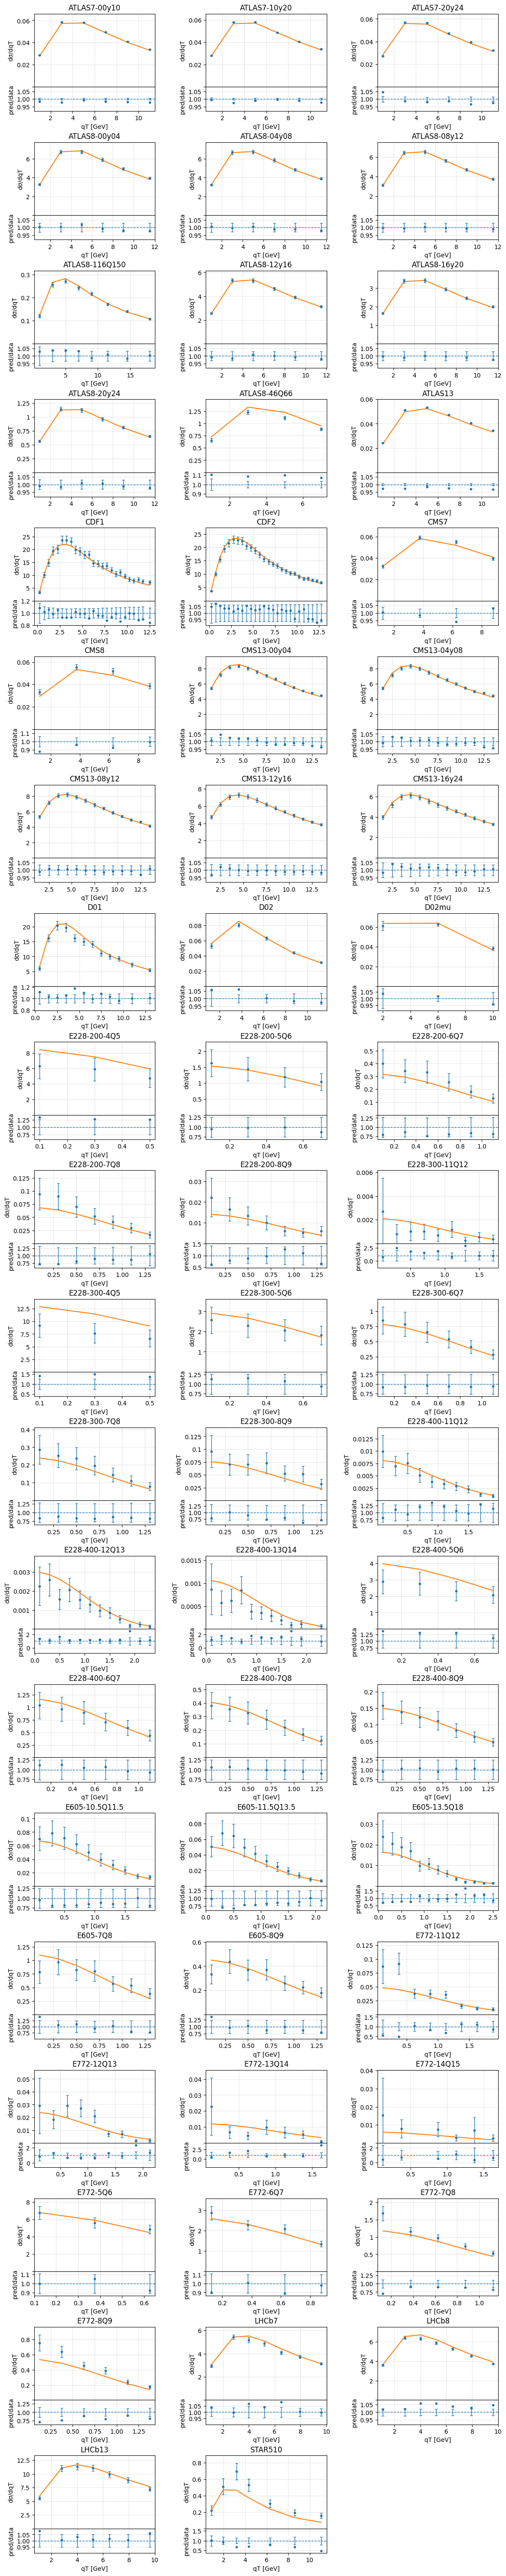

In [21]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# Order to plot (or: sorted(file_names))
files_in_order = list(plots_list.keys())
max_cols_per_row = 3

n_files = len(files_in_order)
if n_files == 0:
    raise ValueError("No files to plot.")

ncols = min(max_cols_per_row, n_files)
nrow_pairs = math.ceil(n_files / ncols)

# Figure & outer grid (spacing BETWEEN files)
fig = plt.figure(figsize=(4.6 * ncols, 3.8 * nrow_pairs))
outer = fig.add_gridspec(nrows=nrow_pairs, ncols=ncols, wspace=0.42, hspace=0.32)

# Hide only the "0" tick label on the spectrum axis
hide_zero_label = FuncFormatter(lambda y, pos: "" if np.isclose(y, 0.0) else f"{y:g}")

def set_spectrum_ylim(ax, y_data, y_err, y_pred, pad_frac=0.12):
    """
    Bottom fixed at 0. Top = max(data+err, prediction) * (1 + pad_frac).
    Purely percentage-based (no fixed absolute padding).
    """
    y_data = np.asarray(y_data, float)
    y_err  = np.asarray(y_err,  float)
    y_pred = np.asarray(y_pred, float)

    data_up = y_data + np.nan_to_num(y_err, nan=0.0)
    candidates = np.concatenate([
        data_up[np.isfinite(data_up)],
        y_pred[np.isfinite(y_pred)]
    ])
    if candidates.size == 0:
        ax.set_ylim(0.0, 1.0)
        return

    ymax = float(np.max(candidates))
    if not np.isfinite(ymax) or ymax <= 0:
        ax.set_ylim(0.0, 1.0)
        return

    ax.set_ylim(0.0, np.nextafter(ymax * (1.0 + pad_frac), np.inf))

def set_ratio_ylim_symmetric_around_one(ax, ratio_vals, ratio_errs,
                                        margin_frac=0.22, min_half_frac=0.08):
    """
    Symmetric about y=1.0, covering ratio points AND 1±err, with percentage-based extra margin.
      - margin_frac: extra headroom as a fraction of the required half-span
      - min_half_frac: minimum half-span as a fraction of 1.0
    """
    r = np.asarray(ratio_vals, float)
    e = np.asarray(ratio_errs, float)
    r_finite = r[np.isfinite(r)]
    e_finite = e[np.isfinite(e)]

    if r_finite.size == 0 and e_finite.size == 0:
        half = max(min_half_frac, 0.10)
        ax.set_ylim(1.0 - half, 1.0 + half)
        return

    lower_from_points = np.min(r_finite) if r_finite.size else np.inf
    upper_from_points = np.max(r_finite) if r_finite.size else -np.inf

    if e_finite.size:
        max_err = float(np.nanmax(e_finite))
        lower_from_errors = 1.0 - max_err
        upper_from_errors = 1.0 + max_err
    else:
        lower_from_errors = np.inf
        upper_from_errors = -np.inf

    lower = min(lower_from_points, lower_from_errors)
    upper = max(upper_from_points, upper_from_errors)

    half_needed = max(1.0 - lower, upper - 1.0, 0.0)
    half = max(half_needed * (1.0 + margin_frac), min_half_frac)
    ax.set_ylim(1.0 - half, 1.0 + half)

for idx, fname in enumerate(files_in_order):
    r = idx // ncols
    c = idx % ncols

    # Inner grid per file: top+bottom, zero vertical gap; share x within the pair
    inner = outer[r, c].subgridspec(nrows=2, ncols=1, height_ratios=[3, 1], hspace=0.0)
    ax_top = fig.add_subplot(inner[0, 0])
    ax_bot = fig.add_subplot(inner[1, 0], sharex=ax_top)

    plot_df = plots_list[fname]
    qT         = plot_df["qT_array"].to_numpy()
    data_vals  = plot_df["data_array"].to_numpy()
    pred_vals  = np.asarray(plot_df["prediction_array"], float)
    data_err   = plot_df["error_uncor_array"].to_numpy()
    ratio_vals = plot_df["ratio_array"].to_numpy()
    ratio_errs = plot_df["error_uncor_ratio_array"].to_numpy()

    # --- Top: data ± error vs prediction ---
    ax_top.errorbar(qT, data_vals, yerr=data_err, fmt='o', ms=3, elinewidth=1, capsize=2, label="data")
    ax_top.plot(qT, pred_vals, linewidth=1.5, label="prediction")
    ax_top.set_title(Path(fname).stem)
    ax_top.set_ylabel("dσ/dqT")
    ax_top.grid(True, alpha=0.3)
    set_spectrum_ylim(ax_top, data_vals, data_err, pred_vals)     # starts at 0, % headroom
    ax_top.yaxis.set_major_formatter(hide_zero_label)             # hide "0" label
    ax_top.tick_params(labelbottom=False)                         # no x labels on top panel
    # show the separator line between panels (keep both spines visible)
    ax_top.spines['bottom'].set_visible(True)
    #if idx == 0:
    #    ax_top.legend(frameon=False)

    # --- Bottom: ratio, symmetric about 1.0 with % margin ---
    ax_bot.axhline(1.0, linestyle="--", linewidth=1)
    ax_bot.plot(qT, ratio_vals, marker='o', linestyle='none', ms=3)
    ax_bot.errorbar(qT, np.ones_like(qT), yerr=ratio_errs, fmt='none', elinewidth=1, capsize=2)
    ax_bot.set_xlabel("qT [GeV]")
    ax_bot.set_ylabel("pred/data")
    ax_bot.grid(True, alpha=0.3)
    set_ratio_ylim_symmetric_around_one(ax_bot, ratio_vals, ratio_errs,
                                        margin_frac=0.22, min_half_frac=0.08)
    ax_bot.spines['top'].set_visible(True)  # separator remains visible

plt.tight_layout()
plt.show()